In [1]:
import json
import boto3
import urllib3

s3 = boto3.client("s3")
http = urllib3.PoolManager()

BUCKET_NAME = "proyecto-electricidad-ela"
S3_KEY = "bronze/calendario/festivos_2024_2025.json"

YEARS = [2024, 2025]
COUNTRY = "ES"

def lambda_handler(event, context):
    all_data = []

    for year in YEARS:
        url = f"https://date.nager.at/api/v3/PublicHolidays/{year}/{COUNTRY}"

        response = http.request("GET", url)

        if response.status != 200:
            return {
                "statusCode": response.status,
                "body": f"Error consultando festivos para {year}"
            }

        data = json.loads(response.data.decode("utf-8"))

        for item in data:
            item["year"] = year

        all_data.extend(data)

    s3.put_object(
        Bucket=BUCKET_NAME,
        Key=S3_KEY,
        Body=json.dumps(all_data, ensure_ascii=False, indent=2).encode("utf-8"),
        ContentType="application/json"
    )

    return {
        "statusCode": 200,
        "body": f"Festivos guardados en s3://{BUCKET_NAME}/{S3_KEY}"
    }

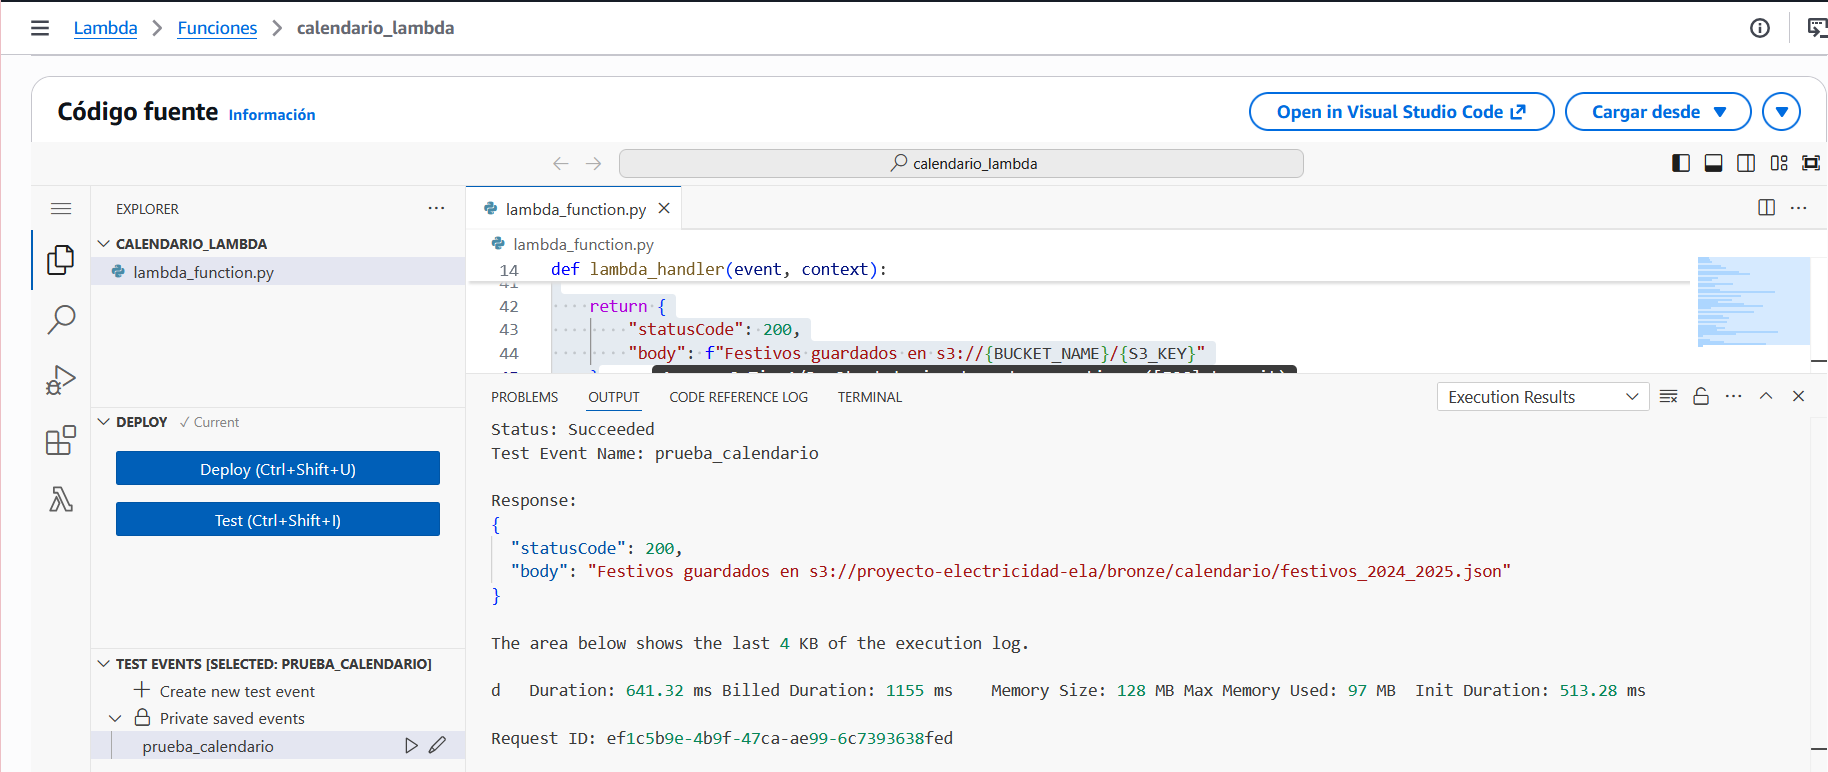